In [4]:
!pip -q install tensorflow scikit-learn matplotlib seaborn requests tqdm opencv-python-headless

import os, time, zipfile, io, requests, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import layers, models, Input, Model

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
DATA_URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
DATA_DIR = "/content/HAR"

if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR, exist_ok=True)
    print("Downloading UCI HAR dataset (~60MB)...")
    r = requests.get(DATA_URL, timeout=120)
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        z.extractall(DATA_DIR)
    # The archive contains a nested "UCI HAR Dataset.zip"
    inner = os.path.join(DATA_DIR, "UCI HAR Dataset.zip")
    if os.path.exists(inner):
        with zipfile.ZipFile(inner) as z:
            z.extractall(DATA_DIR)

BASE = os.path.join(DATA_DIR, "UCI HAR Dataset")
print(os.listdir(BASE))


['README.txt', '.DS_Store', 'activity_labels.txt', 'test', 'features.txt', 'features_info.txt', 'train']


In [6]:
SIGNALS = ["body_acc_x", "body_acc_y", "body_acc_z",
           "body_gyro_x", "body_gyro_y", "body_gyro_z",
           "total_acc_x", "total_acc_y", "total_acc_z"]

def load_signals(subset):
    # subset = 'train' or 'test'
    data = []
    for sig in SIGNALS:
        path = os.path.join(BASE, subset, "Inertial Signals", f"{sig}_{subset}.txt")
        arr = np.loadtxt(path)             # (N, 128)
        data.append(arr)
    X = np.stack(data, axis=-1)            # (N, 128, 9)
    y = np.loadtxt(os.path.join(BASE, subset, f"y_{subset}.txt")).astype(int) - 1  # 0-indexed
    return X, y

X_train_full, y_train_full = load_signals("train")
X_test_full,  y_test_full  = load_signals("test")

ACTIVITY_NAMES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
                   "SITTING", "STANDING", "LAYING"]

print("Full train:", X_train_full.shape, "Full test:", X_test_full.shape)


Full train: (7352, 128, 9) Full test: (2947, 128, 9)


In [7]:
def balanced_subset(X, y, per_class, seed=SEED):
    rng = np.random.RandomState(seed)
    idxs = []
    for c in np.unique(y):
        c_idx = np.where(y == c)[0]
        rng.shuffle(c_idx)
        idxs.extend(c_idx[:per_class])
    idxs = np.array(idxs)
    rng.shuffle(idxs)
    return X[idxs], y[idxs]

# ~2400 training windows total, balanced across 6 classes (400 each), preserving all classes
X_sub, y_sub = balanced_subset(X_train_full, y_train_full, per_class=400)

# 70/15/15 split (train/val from the subset; test = official UCI HAR test set, subsampled to 15% equiv.)
n = len(X_sub)
n_train = int(0.70 / 0.85 * n)   # train is 70% of (train+val)
perm = np.random.permutation(n)
X_sub, y_sub = X_sub[perm], y_sub[perm]
X_train, y_train = X_sub[:n_train], y_sub[:n_train]
X_val,   y_val   = X_sub[n_train:], y_sub[n_train:]

# Test set: balanced subsample of the official test partition (~15% of total data volume)
X_test, y_test = balanced_subset(X_test_full, y_test_full, per_class=90)

# Normalize using TRAIN statistics only (per-channel)
n_train_pts, T, F = X_train.shape
scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, F))

def normalize(X):
    shp = X.shape
    return scaler.transform(X.reshape(-1, F)).reshape(shp)

X_train_n, X_val_n, X_test_n = normalize(X_train), normalize(X_val), normalize(X_test)

print("Input tensor shape:")
print(f"  Training   : {X_train_n.shape}")
print(f"  Validation : {X_val_n.shape}")
print(f"  Testing    : {X_test_n.shape}")
print("Number of classes:", len(ACTIVITY_NAMES))
print("Number of features per time step:", F)
print("Sequence length:", T)

for name, y_ in [("train", y_train), ("val", y_val), ("test", y_test)]:
    vals, counts = np.unique(y_, return_counts=True)
    print(name, dict(zip([ACTIVITY_NAMES[v] for v in vals], counts)))


Input tensor shape:
  Training   : (1976, 128, 9)
  Validation : (424, 128, 9)
  Testing    : (540, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128
train {'WALKING': np.int64(330), 'WALKING_UPSTAIRS': np.int64(329), 'WALKING_DOWNSTAIRS': np.int64(324), 'SITTING': np.int64(328), 'STANDING': np.int64(337), 'LAYING': np.int64(328)}
val {'WALKING': np.int64(70), 'WALKING_UPSTAIRS': np.int64(71), 'WALKING_DOWNSTAIRS': np.int64(76), 'SITTING': np.int64(72), 'STANDING': np.int64(63), 'LAYING': np.int64(72)}
test {'WALKING': np.int64(90), 'WALKING_UPSTAIRS': np.int64(90), 'WALKING_DOWNSTAIRS': np.int64(90), 'SITTING': np.int64(90), 'STANDING': np.int64(90), 'LAYING': np.int64(90)}


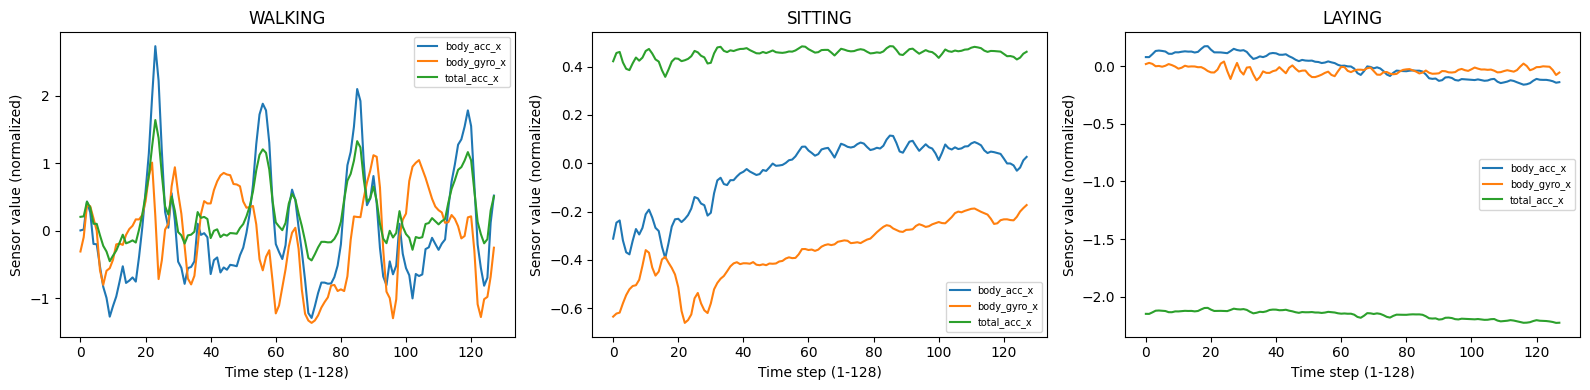

In [8]:
def plot_sample(ax, X, y, activity_idx, channels, channel_names):
    idx = np.where(y == activity_idx)[0][0]
    for ch, cname in zip(channels, channel_names):
        ax.plot(X[idx, :, ch], label=cname)
    ax.set_title(ACTIVITY_NAMES[activity_idx])
    ax.set_xlabel("Time step (1-128)")
    ax.set_ylabel("Sensor value (normalized)")
    ax.legend(fontsize=7)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
channels = [0, 3, 6]                                  # body_acc_x, body_gyro_x, total_acc_x
channel_names = ["body_acc_x", "body_gyro_x", "total_acc_x"]
for ax, act in zip(axes, [0, 3, 5]):                   # WALKING, SITTING, LAYING
    plot_sample(ax, X_train_n, y_train, act, channels, channel_names)
plt.tight_layout(); plt.show()


In [32]:
def build_model(rnn_type="SimpleRNN", units=32, input_shape=(128, 9), n_classes=6, stacked=False, bidirectional=False):
    layer_map = {"SimpleRNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}
    Rec = layer_map[rnn_type]

    inp = Input(shape=input_shape)
    x = inp
    if stacked:
        rec1 = Rec(units, return_sequences=True)
        if bidirectional:
            rec1 = layers.Bidirectional(rec1)
        x = rec1(x)
        rec2 = Rec(units, return_sequences=False)
        if bidirectional:
            rec2 = layers.Bidirectional(rec2)
        x = rec2(x)
    else:
        rec = Rec(units, return_sequences=False)
        if bidirectional:
            rec = layers.Bidirectional(rec)
        x = rec(x)

    x = layers.Dropout(0.2)(x)
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(n_classes, activation="softmax")(x)
    model = Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def train_and_time(model, X_tr, y_tr, X_v, y_v, epochs=30, batch_size=32, verbose=0):
    t0 = time.time()
    hist = model.fit(X_tr, y_tr, validation_data=(X_v, y_v),
                      epochs=epochs, batch_size=batch_size, verbose=verbose)
    train_time = time.time() - t0
    return hist, train_time

def evaluate_model(model, X_te, y_te, class_names=ACTIVITY_NAMES):
    y_prob = model.predict(X_te, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_te, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_te, y_pred, average="macro", zero_division=0)
    # Force the confusion matrix to include every class (0..n-1), even if a class happens to be
    # absent from this particular test split (common with small video subsets).
    all_labels = list(range(len(class_names)))
    cm = confusion_matrix(y_te, y_pred, labels=all_labels)
    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1, cm=cm, y_pred=y_pred)

In [33]:
EPOCHS = 30
results = {}
histories = {}

for name in ["SimpleRNN", "LSTM", "GRU"]:
    print(f"\n=== Training {name} ===")
    tf.random.set_seed(SEED)
    model = build_model(rnn_type=name, units=32)
    hist, train_time = train_and_time(model, X_train_n, y_train, X_val_n, y_val, epochs=EPOCHS, verbose=2)
    metrics = evaluate_model(model, X_test_n, y_test)
    n_params = model.count_params()
    results[name] = dict(metrics=metrics, train_time=train_time, n_params=n_params, model=model)
    histories[name] = hist
    print(f"{name}: acc={metrics['accuracy']:.4f} f1={metrics['f1']:.4f} "
          f"params={n_params} time={train_time:.1f}s")



=== Training SimpleRNN ===
Epoch 1/30
62/62 - 11s - 176ms/step - accuracy: 0.4140 - loss: 1.5468 - val_accuracy: 0.5142 - val_loss: 1.2752
Epoch 2/30
62/62 - 3s - 56ms/step - accuracy: 0.5562 - loss: 1.1402 - val_accuracy: 0.5708 - val_loss: 1.0123
Epoch 3/30
62/62 - 1s - 14ms/step - accuracy: 0.6199 - loss: 0.9113 - val_accuracy: 0.6226 - val_loss: 0.8505
Epoch 4/30
62/62 - 1s - 21ms/step - accuracy: 0.6437 - loss: 0.8053 - val_accuracy: 0.6297 - val_loss: 0.7615
Epoch 5/30
62/62 - 1s - 17ms/step - accuracy: 0.6690 - loss: 0.7366 - val_accuracy: 0.6274 - val_loss: 0.7339
Epoch 6/30
62/62 - 1s - 11ms/step - accuracy: 0.7004 - loss: 0.6680 - val_accuracy: 0.6533 - val_loss: 0.6986
Epoch 7/30
62/62 - 1s - 11ms/step - accuracy: 0.6994 - loss: 0.6484 - val_accuracy: 0.6627 - val_loss: 0.6822
Epoch 8/30
62/62 - 1s - 11ms/step - accuracy: 0.7120 - loss: 0.6761 - val_accuracy: 0.6840 - val_loss: 0.6719
Epoch 9/30
62/62 - 1s - 11ms/step - accuracy: 0.7358 - loss: 0.6007 - val_accuracy: 0.6816

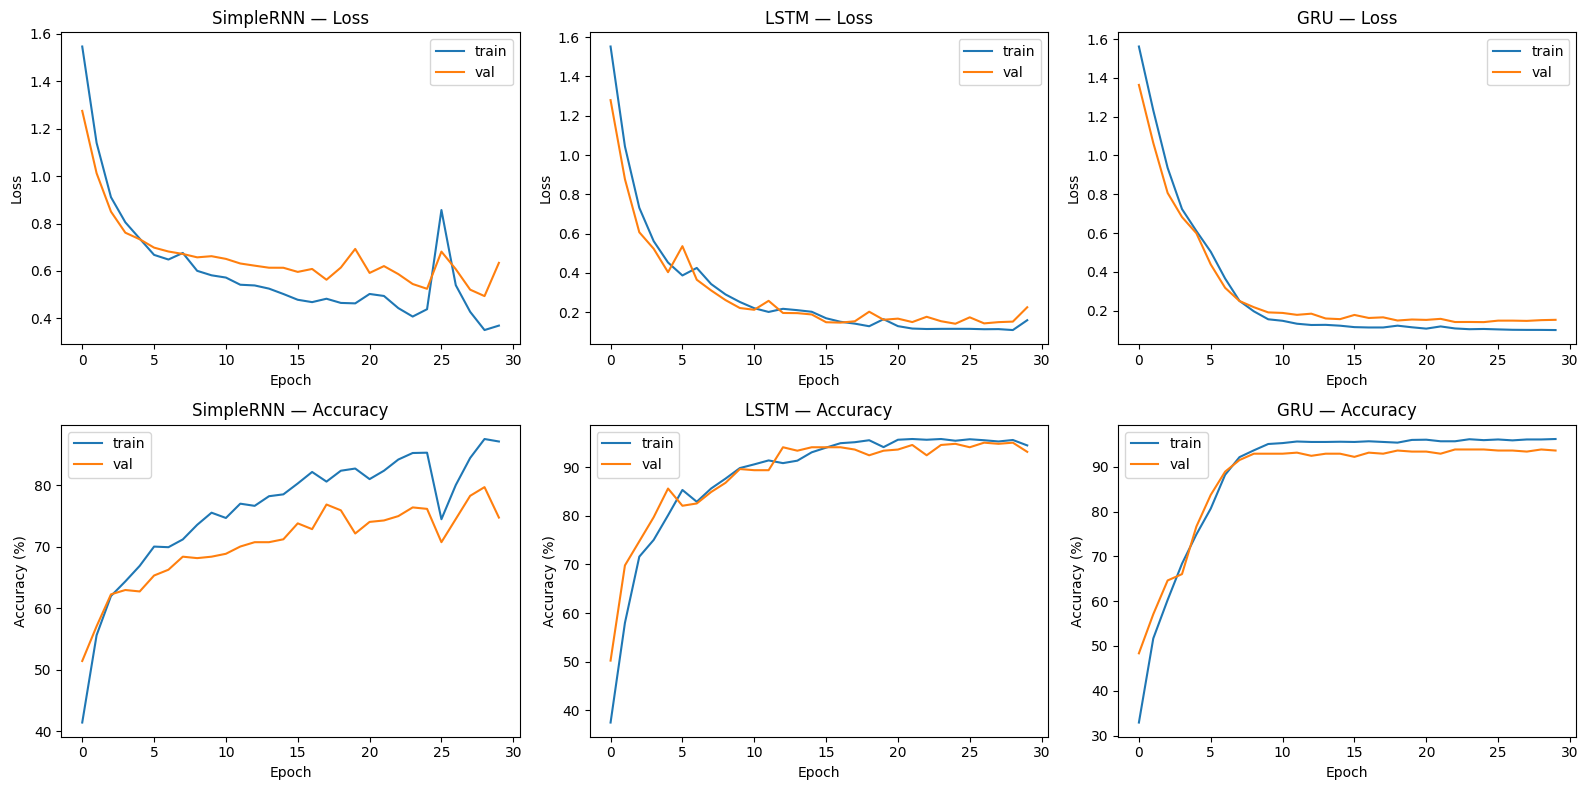

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, name in enumerate(["SimpleRNN", "LSTM", "GRU"]):
    h = histories[name].history
    axes[0, i].plot(h["loss"], label="train")
    axes[0, i].plot(h["val_loss"], label="val")
    axes[0, i].set_title(f"{name} — Loss"); axes[0, i].set_xlabel("Epoch"); axes[0, i].set_ylabel("Loss"); axes[0, i].legend()

    axes[1, i].plot(np.array(h["accuracy"]) * 100, label="train")
    axes[1, i].plot(np.array(h["val_accuracy"]) * 100, label="val")
    axes[1, i].set_title(f"{name} — Accuracy"); axes[1, i].set_xlabel("Epoch"); axes[1, i].set_ylabel("Accuracy (%)"); axes[1, i].legend()

plt.tight_layout(); plt.show()


In [35]:
rows = []
for name in ["SimpleRNN", "LSTM", "GRU"]:
    m = results[name]["metrics"]
    rows.append({
        "Model": name,
        "Accuracy (%)": round(m["accuracy"] * 100, 2),
        "Macro Precision (%)": round(m["precision"] * 100, 2),
        "Macro Recall (%)": round(m["recall"] * 100, 2),
        "Macro F1 (%)": round(m["f1"] * 100, 2),
        "Parameters": results[name]["n_params"],
        "Training Time (s)": round(results[name]["train_time"], 2),
    })
perf_df = pd.DataFrame(rows).set_index("Model")
perf_df


,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
Model,,,,,,
SimpleRNN,74.63,76.42,74.63,74.64,1974,36.18
LSTM,89.07,90.00,89.07,89.14,6006,22.80
GRU,90.19,90.28,90.19,90.19,4758,21.84


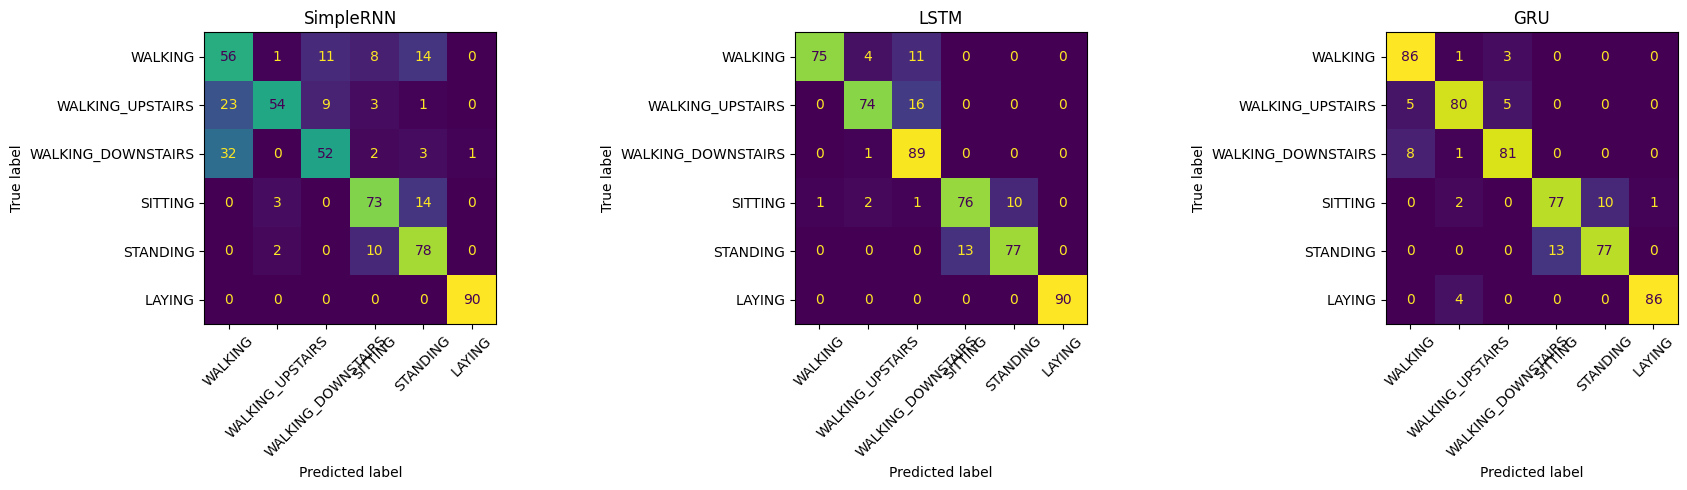

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name in zip(axes, ["SimpleRNN", "LSTM", "GRU"]):
    cm = results[name]["metrics"]["cm"]
    disp = ConfusionMatrixDisplay(cm, display_labels=ACTIVITY_NAMES)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.show()


,RNN,LSTM,GRU
Property,,,
Hidden state,Yes,Yes,Yes
Cell state,No,Yes,No
Forget gate,No,Yes,No
Input gate,No,Yes,No
Output gate,No,Yes,No
Update gate,No,No,Yes
Reset gate,No,No,Yes
Parameters,1974,6006,4758
Training time (s),36.18,22.8,21.84


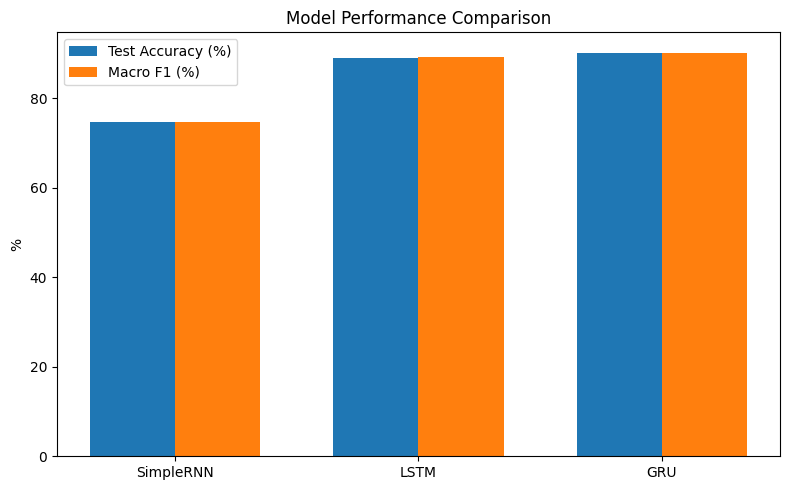

In [37]:
comparison = pd.DataFrame({
    "Property": ["Hidden state", "Cell state", "Forget gate", "Input gate", "Output gate",
                 "Update gate", "Reset gate", "Parameters", "Training time (s)", "Test F1-score"],
    "RNN":  ["Yes", "No", "No", "No", "No", "No", "No",
             results["SimpleRNN"]["n_params"], round(results["SimpleRNN"]["train_time"], 2),
             round(results["SimpleRNN"]["metrics"]["f1"], 4)],
    "LSTM": ["Yes", "Yes", "Yes", "Yes", "Yes", "No", "No",
             results["LSTM"]["n_params"], round(results["LSTM"]["train_time"], 2),
             round(results["LSTM"]["metrics"]["f1"], 4)],
    "GRU":  ["Yes", "No", "No", "No", "No", "Yes", "Yes",
             results["GRU"]["n_params"], round(results["GRU"]["train_time"], 2),
             round(results["GRU"]["metrics"]["f1"], 4)],
})
display(comparison.set_index("Property"))

fig, ax = plt.subplots(figsize=(8, 5))
names = ["SimpleRNN", "LSTM", "GRU"]
acc = [results[n]["metrics"]["accuracy"] * 100 for n in names]
f1 = [results[n]["metrics"]["f1"] * 100 for n in names]
x_pos = np.arange(len(names)); w = 0.35
ax.bar(x_pos - w/2, acc, width=w, label="Test Accuracy (%)")
ax.bar(x_pos + w/2, f1, width=w, label="Macro F1 (%)")
ax.set_xticks(x_pos); ax.set_xticklabels(names)
ax.set_ylabel("%"); ax.set_title("Model Performance Comparison"); ax.legend()
plt.tight_layout(); plt.show()


T= 32 SimpleRNN  F1=0.6911
T= 32 LSTM       F1=0.8652
T= 32 GRU        F1=0.9108
T= 64 SimpleRNN  F1=0.6450
T= 64 LSTM       F1=0.8684
T= 64 GRU        F1=0.8927
T=128 SimpleRNN  F1=0.7360
T=128 LSTM       F1=0.9075
T=128 GRU        F1=0.9034


,SimpleRNN,LSTM,GRU
Sequence Length,,,
32,0.691089,0.865212,0.910828
64,0.644970,0.868418,0.892674
128,0.736018,0.907468,0.903442


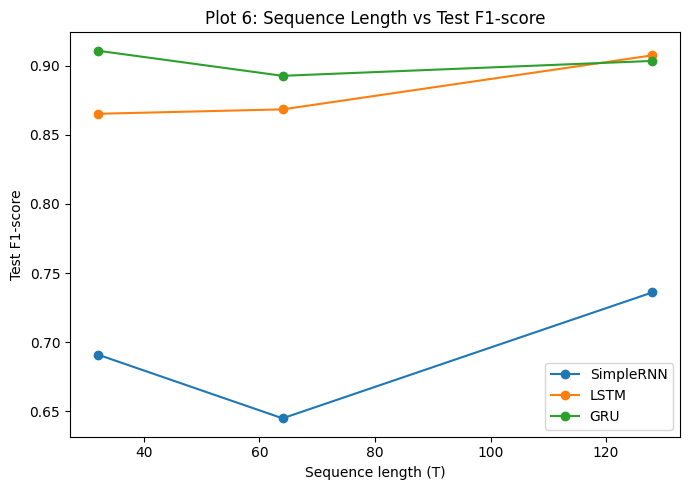

In [38]:
def truncate_seq(X, T_new):
    return X[:, :T_new, :]

seq_lengths = [32, 64, 128]
seqlen_results = {name: [] for name in ["SimpleRNN", "LSTM", "GRU"]}

for T_new in seq_lengths:
    Xtr_t = truncate_seq(X_train_n, T_new)
    Xv_t  = truncate_seq(X_val_n, T_new)
    Xte_t = truncate_seq(X_test_n, T_new)
    for name in ["SimpleRNN", "LSTM", "GRU"]:
        tf.random.set_seed(SEED)
        model = build_model(rnn_type=name, units=32, input_shape=(T_new, F))
        model.fit(Xtr_t, y_train, validation_data=(Xv_t, y_val), epochs=15, batch_size=32, verbose=0)
        m = evaluate_model(model, Xte_t, y_test)
        seqlen_results[name].append(m["f1"])
        print(f"T={T_new:3d} {name:10s} F1={m['f1']:.4f}")

seqlen_df = pd.DataFrame(seqlen_results, index=seq_lengths)
seqlen_df.index.name = "Sequence Length"
display(seqlen_df)

fig, ax = plt.subplots(figsize=(7, 5))
for name in ["SimpleRNN", "LSTM", "GRU"]:
    ax.plot(seq_lengths, seqlen_df[name], marker="o", label=name)
ax.set_xlabel("Sequence length (T)"); ax.set_ylabel("Test F1-score")
ax.set_title("Plot 6: Sequence Length vs Test F1-score"); ax.legend()
plt.tight_layout(); plt.show()


In [39]:
!pip -q install remotezip

import remotezip as rz
import tqdm, random as pyrandom, collections

VIDEO_ROOT = "/content/ucf_subset"   # structure created below: VIDEO_ROOT/<class_name>/*.avi
SELECTED_CLASSES = ["Basketball", "Biking", "WalkingWithDog", "JumpRope", "TennisSwing"]
VIDEOS_PER_CLASS = 8                 # small subset -> fast to download & train
N_FRAMES = 10
IMG_SIZE = 224

# The original Google-hosted mirror (used by TF's official tutorial) can return 403 if access is
# revoked. This Hugging Face mirror re-zips the official UCF-101 release and supports the same
# range-request streaming, so only the requested files are pulled, not the full ~7GB archive.
UCF_ZIP_URLS = [
    "https://huggingface.co/datasets/quchenyuan/UCF101-ZIP/resolve/main/UCF-101.zip",
    "https://storage.googleapis.com/thumos14_files/UCF101_videos.zip",
]

def download_ucf_subset(zip_url, classes, videos_per_class, download_dir):
    os.makedirs(download_dir, exist_ok=True)
    with rz.RemoteZip(zip_url) as zip_ref:
        all_files = zip_ref.namelist()
        got_any = False
        for cls in classes:
            matches = [f for f in all_files if f"_{cls}_" in f]
            if not matches:
                print(f"  (!) no files found for class '{cls}' — check spelling against UCF101 class names")
                continue
            pyrandom.shuffle(matches)
            chosen = matches[:videos_per_class]
            cls_dir = os.path.join(download_dir, cls)
            os.makedirs(cls_dir, exist_ok=True)
            for f in tqdm.tqdm(chosen, desc=cls):
                zip_ref.extract(f, cls_dir)
                extracted_path = os.path.join(cls_dir, f)
                target_path = os.path.join(cls_dir, os.path.basename(f))
                if extracted_path != target_path and os.path.exists(extracted_path):
                    os.replace(extracted_path, target_path)
                got_any = True
    return got_any

def have_videos(download_dir):
    if not os.path.isdir(download_dir):
        return False
    for _, _, files in os.walk(download_dir):
        if any(f.lower().endswith((".avi", ".mp4")) for f in files):
            return True
    return False

if not have_videos(VIDEO_ROOT):
    for url in UCF_ZIP_URLS:
        print(f"Trying source: {url}")
        try:
            ok = download_ucf_subset(url, SELECTED_CLASSES, VIDEOS_PER_CLASS, VIDEO_ROOT)
            if ok:
                print("Download succeeded from this source.")
                break
        except Exception as e:
            print(f"  (!) source failed: {e}")
    else:
        print("All sources failed. See the markdown note above this cell for a manual fallback.")

# Clean up any leftover empty nested folders from extraction
for cls in SELECTED_CLASSES:
    cls_dir = os.path.join(VIDEO_ROOT, cls)
    if os.path.isdir(cls_dir):
        for root, dirs, files in os.walk(cls_dir, topdown=False):
            if root != cls_dir and not os.listdir(root):
                os.rmdir(root)

video_paths, video_labels = [], []
if os.path.isdir(VIDEO_ROOT):
    for cls in SELECTED_CLASSES:
        cls_dir = os.path.join(VIDEO_ROOT, cls)
        if not os.path.isdir(cls_dir):
            continue
        for dirpath, _, filenames in os.walk(cls_dir):
            for fname in filenames:
                if fname.lower().endswith((".avi", ".mp4")):
                    video_paths.append(os.path.join(dirpath, fname))
                    video_labels.append(cls)

print(f"Found {len(video_paths)} videos across {len(set(video_labels))} classes.")
print("If this is 0, re-run this cell (network hiccup), try different SELECTED_CLASSES, or see the manual fallback note above.")


Found 40 videos across 5 classes.
If this is 0, re-run this cell (network hiccup), try different SELECTED_CLASSES, or see the manual fallback note above.


In [40]:
# --- Frame sampling utility ---
import cv2

def sample_frames(video_path, n_frames=N_FRAMES, img_size=IMG_SIZE):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return None
    idxs = np.linspace(0, max(total - 1, 0), n_frames).astype(int)
    frames = []
    for i in range(total):
        ret, frame = cap.read()
        if not ret:
            break
        if i in idxs:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))
            frames.append(frame)
    cap.release()
    if len(frames) < n_frames:
        return None
    return np.stack(frames[:n_frames])   # (10, 224, 224, 3)

# --- CNN feature extraction (frozen MobileNetV2) ---
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

cnn_base = MobileNetV2(include_top=False, weights="imagenet", pooling="avg",
                        input_shape=(IMG_SIZE, IMG_SIZE, 3))
cnn_base.trainable = False    # freeze — do NOT train the CNN
FEATURE_DIM = cnn_base.output_shape[-1]
print("CNN feature dimension D =", FEATURE_DIM)

def extract_video_features(video_paths):
    feats, labels_kept, sample_frames_for_plot = [], [], None
    for i, vp in enumerate(video_paths):
        frames = sample_frames(vp)
        if frames is None:
            continue
        x = preprocess_input(frames.astype(np.float32))
        f = cnn_base.predict(x, verbose=0)          # (10, D)
        feats.append(f)
        labels_kept.append(video_labels[i])
        if sample_frames_for_plot is None:
            sample_frames_for_plot = frames
    return (np.stack(feats) if feats else np.empty((0, N_FRAMES, FEATURE_DIM)),
            labels_kept, sample_frames_for_plot)

if len(video_paths) > 0:
    X_vid_feats, y_vid_labels, sample_frames_plot = extract_video_features(video_paths)
    class_to_idx = {c: i for i, c in enumerate(sorted(set(y_vid_labels)))}
    y_vid = np.array([class_to_idx[c] for c in y_vid_labels])
    print("Feature tensor supplied to recurrent network:", X_vid_feats.shape)
else:
    X_vid_feats, y_vid, sample_frames_plot, class_to_idx = None, None, None, None
    print("Skipping — no videos found. Populate", VIDEO_ROOT, "and re-run this cell.")


CNN feature dimension D = 1280
Feature tensor supplied to recurrent network: (36, 10, 1280)


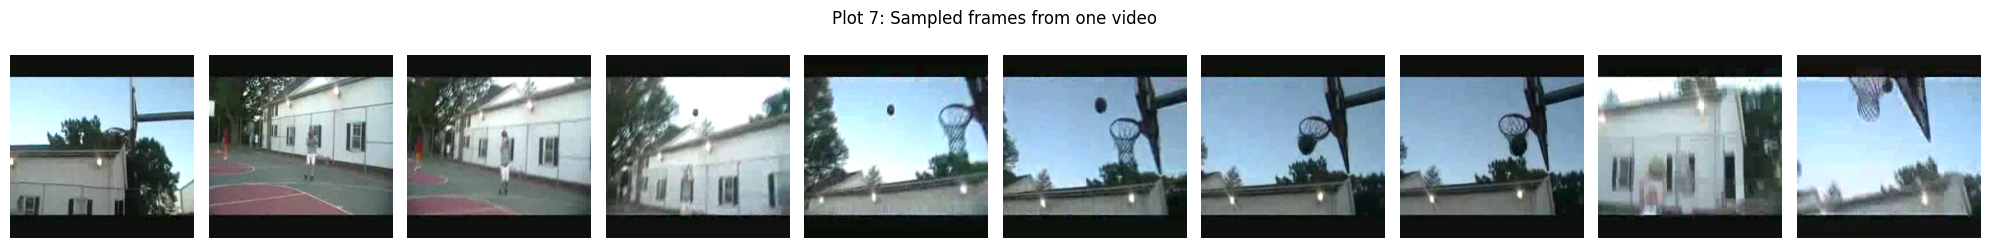

In [41]:
# Plot 7: representative sampled frames from one video
if sample_frames_plot is not None:
    fig, axes = plt.subplots(1, N_FRAMES, figsize=(20, 2.5))
    for ax, fr in zip(axes, sample_frames_plot):
        ax.imshow(fr); ax.axis("off")
    plt.suptitle("Plot 7: Sampled frames from one video")
    plt.tight_layout(); plt.show()


CNN-LSTM: acc=0.667 f1=0.600
CNN-GRU: acc=0.667 f1=0.600


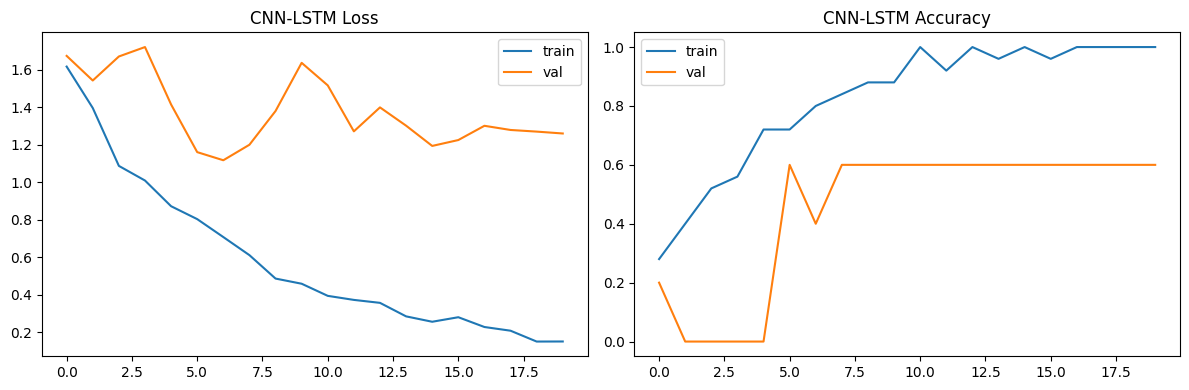

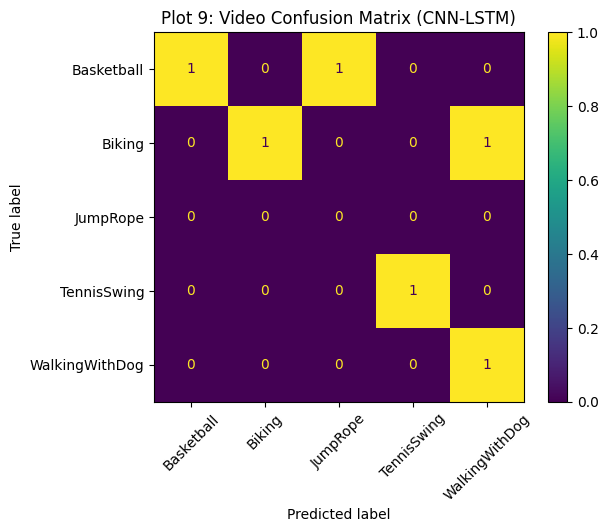

Predicted class: JumpRope
Actual class   : Basketball
Confidence     : 0.98


In [44]:
# Train/val/test split + CNN-LSTM / CNN-GRU classifier
if X_vid_feats is not None and len(X_vid_feats) >= 10:
    n_v = len(X_vid_feats)
    perm = np.random.permutation(n_v)
    X_vid_feats, y_vid = X_vid_feats[perm], y_vid[perm]
    n_tr = int(0.7 * n_v); n_va = int(0.15 * n_v)
    Xv_tr, yv_tr = X_vid_feats[:n_tr], y_vid[:n_tr]
    Xv_va, yv_va = X_vid_feats[n_tr:n_tr+n_va], y_vid[n_tr:n_tr+n_va]
    Xv_te, yv_te = X_vid_feats[n_tr+n_va:], y_vid[n_tr+n_va:]
    n_vid_classes = len(class_to_idx)

    video_results = {}
    for rtype in ["LSTM", "GRU"]:
        tf.random.set_seed(SEED)
        vmodel = build_model(rnn_type=rtype, units=32, input_shape=(N_FRAMES, FEATURE_DIM), n_classes=n_vid_classes)
        vhist, vtime = train_and_time(vmodel, Xv_tr, yv_tr, Xv_va, yv_va, epochs=20, batch_size=8, verbose=0)
        vmetrics = evaluate_model(vmodel, Xv_te, yv_te, class_names=list(class_to_idx.keys()))
        video_results[rtype] = dict(hist=vhist, metrics=vmetrics, time=vtime, model=vmodel)
        print(f"CNN-{rtype}: acc={vmetrics['accuracy']:.3f} f1={vmetrics['f1']:.3f}")

    # Plot 8: training curves for chosen recurrent architecture (LSTM shown)
    h = video_results["LSTM"]["hist"].history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(h["loss"], label="train"); axes[0].plot(h["val_loss"], label="val")
    axes[0].set_title("CNN-LSTM Loss"); axes[0].legend()
    axes[1].plot(h["accuracy"], label="train"); axes[1].plot(h["val_accuracy"], label="val")
    axes[1].set_title("CNN-LSTM Accuracy"); axes[1].legend()
    plt.tight_layout(); plt.show()

    # Plot 9: confusion matrix
    cm = video_results["LSTM"]["metrics"]["cm"]
    ConfusionMatrixDisplay(cm, display_labels=list(class_to_idx.keys())).plot(xticks_rotation=45)
    plt.title("Plot 9: Video Confusion Matrix (CNN-LSTM)")
    plt.show()

    # Example prediction with genuine confidence from the trained model
    probs = video_results["LSTM"]["model"].predict(Xv_te[:1], verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    print("Predicted class:", idx_to_class[pred_idx])
    print("Actual class   :", idx_to_class[int(yv_te[0])])
    print(f"Confidence     : {probs[pred_idx]:.2f}")
else:
    print("Skipping video training — populate", VIDEO_ROOT, "with a small UCF101 subset first.")


In [45]:
VOCAB_SIZE = 10          # integers 0-9
SEQ_LEN = 4
N_SAMPLES = 8000

def make_reversal_dataset(n_samples, seq_len, vocab_size, seed=SEED):
    rng = np.random.RandomState(seed)
    X = rng.randint(0, vocab_size, size=(n_samples, seq_len))
    Y = X[:, ::-1]
    return X, Y

X_seq, Y_seq = make_reversal_dataset(N_SAMPLES, SEQ_LEN, VOCAB_SIZE)

n = len(X_seq)
n_tr = int(0.7 * n); n_va = int(0.15 * n)
Xs_tr, Ys_tr = X_seq[:n_tr], Y_seq[:n_tr]
Xs_va, Ys_va = X_seq[n_tr:n_tr+n_va], Y_seq[n_tr:n_tr+n_va]
Xs_te, Ys_te = X_seq[n_tr+n_va:], Y_seq[n_tr+n_va:]

print("Example:", X_seq[0].tolist(), "->", Y_seq[0].tolist())


Example: [6, 3, 7, 4] -> [4, 7, 3, 6]


In [62]:
# Encoder-decoder (teacher forcing during training)
EMB_DIM = 16
LATENT = 32

# Decoder input = <SOS> + target[:-1]  (SOS token = VOCAB_SIZE, so vocab becomes VOCAB_SIZE+1)
SOS = VOCAB_SIZE
FULL_VOCAB = VOCAB_SIZE + 1

def make_decoder_input(Y):
    sos_col = np.full((Y.shape[0], 1), SOS)
    return np.concatenate([sos_col, Y[:, :-1]], axis=1)

Ys_tr_in = make_decoder_input(Ys_tr)
Ys_va_in = make_decoder_input(Ys_va)
Ys_te_in = make_decoder_input(Ys_te)

# IMPORTANT: every layer is saved to a named variable so the exact same trained layer
# (weights included) can be reused later to build the standalone inference models.
enc_embedding_layer = layers.Embedding(FULL_VOCAB, EMB_DIM, name="enc_embedding")
enc_lstm_layer = layers.LSTM(LATENT, return_state=True, name="enc_lstm")
dec_embedding_layer = layers.Embedding(FULL_VOCAB, EMB_DIM, name="dec_embedding")
dec_lstm = layers.LSTM(LATENT, return_sequences=True, return_state=True, name="dec_lstm")
dec_dense = layers.Dense(FULL_VOCAB, activation="softmax", name="dec_dense")

enc_inputs = Input(shape=(SEQ_LEN,), name="encoder_input")
enc_emb = enc_embedding_layer(enc_inputs)
_, state_h, state_c = enc_lstm_layer(enc_emb)
encoder_states = [state_h, state_c]

dec_inputs = Input(shape=(SEQ_LEN,), name="decoder_input")
dec_emb = dec_embedding_layer(dec_inputs)
dec_out, _, _ = dec_lstm(dec_emb, initial_state=encoder_states)
outputs = dec_dense(dec_out)

seq2seq_model = Model([enc_inputs, dec_inputs], outputs)
seq2seq_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
seq2seq_model.summary()


Model: "functional_54"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_embedding       │ (None, 4, 16)     │        176 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_embedding       │ (None, 4, 16)     │        176 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_lstm (LSTM)     │ [(None, 32),      │      6,272 │ enc_embedding[0]… │
│                     │ (None, 32),       │            │                   │
│                     │ (None, 32)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_lstm (LSTM)     │ [(None, 4, 32),   │      6,272 │ dec_embedding[0]… │
│                     │ (None, 32),       │            │ enc_lstm[0][1],   │
│                     │ (None, 32)]       │            │ enc_lstm[0][2]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_dense (Dense)   │ (None, 4, 11)     │        363 │ dec_lstm[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,259 (51.79 KB)

 Trainable params: 13,259 (51.79 KB)

 Non-trainable params: 0 (0.00 B)

Final train loss: 0.005568758584558964
Final val loss  : 0.006346248555928469


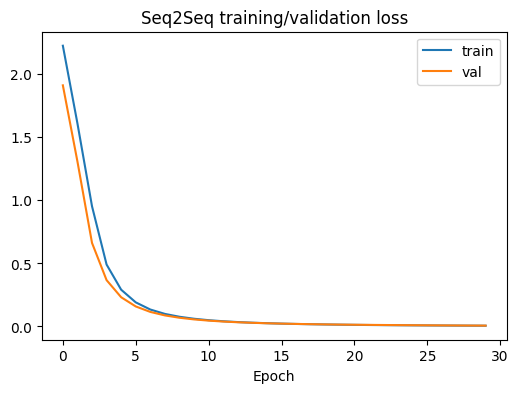

In [63]:
seq2seq_hist = seq2seq_model.fit(
    [Xs_tr, Ys_tr_in], Ys_tr,
    validation_data=([Xs_va, Ys_va_in], Ys_va),
    epochs=30, batch_size=64, verbose=0)

print("Final train loss:", seq2seq_hist.history["loss"][-1])
print("Final val loss  :", seq2seq_hist.history["val_loss"][-1])

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(seq2seq_hist.history["loss"], label="train")
ax.plot(seq2seq_hist.history["val_loss"], label="val")
ax.set_title("Seq2Seq training/validation loss"); ax.set_xlabel("Epoch"); ax.legend()
plt.show()


In [64]:
# Greedy inference (no teacher forcing at test time)
# Build standalone encoder/decoder inference models, REUSING the exact trained layers
# (enc_embedding_layer, enc_lstm_layer, dec_embedding_layer, dec_lstm, dec_dense) defined above.
# Creating fresh layers here (instead of reusing the trained ones) is a common bug that leads to
# untrained/random weights being used at inference time, even though training loss looks fine.
enc_model = Model(enc_inputs, encoder_states)

dec_state_h_in = Input(shape=(LATENT,))
dec_state_c_in = Input(shape=(LATENT,))
dec_single_input = Input(shape=(1,))
dec_single_emb = dec_embedding_layer(dec_single_input)          # reuse trained embedding
dec_single_out, dh, dc = dec_lstm(dec_single_emb, initial_state=[dec_state_h_in, dec_state_c_in])
dec_single_pred = dec_dense(dec_single_out)                     # reuse trained dense layer
dec_model = Model([dec_single_input, dec_state_h_in, dec_state_c_in], [dec_single_pred, dh, dc])

def predict_sequences_batch(X):
    h, c = enc_model.predict(X, verbose=0)          # (N, LATENT), (N, LATENT)
    tok = np.full((len(X), 1), SOS)
    outputs = []
    for _ in range(SEQ_LEN):
        pred, h, c = dec_model.predict([tok, h, c], verbose=0)
        next_tok = np.argmax(pred[:, -1, :], axis=-1)  # (N,)
        outputs.append(next_tok)
        tok = next_tok[:, None]
    return np.stack(outputs, axis=1)  # (N, SEQ_LEN)

predictions_arr = predict_sequences_batch(Xs_te)
predictions = predictions_arr.tolist()

correct_tokens = int((predictions_arr == Ys_te).sum())
total_tokens = predictions_arr.size
correct_seqs = int((predictions_arr == Ys_te).all(axis=1).sum())

token_acc = correct_tokens / total_tokens
seq_acc = correct_seqs / len(Xs_te)
print(f"Token accuracy    : {token_acc:.4f}")
print(f"Sequence accuracy : {seq_acc:.4f}")

print("\nSample Input Sequence -> Predicted Output")
for i in range(5):
    print(f"{Xs_te[i].tolist()} -> {predictions[i]}  (actual: {Ys_te[i].tolist()})")


Token accuracy    : 1.0000
Sequence accuracy : 1.0000

Sample Input Sequence -> Predicted Output
[6, 3, 0, 8] -> [8, 0, 3, 6]  (actual: [8, 0, 3, 6])
[5, 8, 2, 4] -> [4, 2, 8, 5]  (actual: [4, 2, 8, 5])
[8, 5, 1, 0] -> [0, 1, 5, 8]  (actual: [0, 1, 5, 8])
[8, 0, 4, 0] -> [0, 4, 0, 8]  (actual: [0, 4, 0, 8])
[4, 4, 6, 6] -> [6, 6, 4, 4]  (actual: [6, 6, 4, 4])


In [65]:
consolidated = perf_df.copy()
consolidated


,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
Model,,,,,,
SimpleRNN,74.63,76.42,74.63,74.64,1974,36.18
LSTM,89.07,90.00,89.07,89.14,6006,22.80
GRU,90.19,90.28,90.19,90.19,4758,21.84


In [66]:
if 'video_results' in dir() and X_vid_feats is not None and len(X_vid_feats) >= 10:
    vid_rows = []
    for name in ["LSTM", "GRU"]:
        vm = video_results[name]["metrics"]
        vid_rows.append({"Model": f"CNN-{name}",
                          "Accuracy (%)": round(vm["accuracy"]*100, 2),
                          "Macro Precision (%)": round(vm["precision"]*100, 2),
                          "Macro Recall (%)": round(vm["recall"]*100, 2),
                          "Macro F1 (%)": round(vm["f1"]*100, 2),
                          "Parameters": video_results[name]["model"].count_params()})
    vid_df = pd.DataFrame(vid_rows).set_index("Model")
    display(vid_df)
else:
    print("Video results unavailable (no UCF101 subset was found).")


,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters
Model,,,,,
CNN-LSTM,66.67,70.0,60.0,60.0,168677
CNN-GRU,66.67,70.0,60.0,60.0,126757


In [67]:
seq2seq_table = pd.DataFrame({
    "Metric": ["Token accuracy", "Sequence accuracy", "Final training loss", "Final validation loss"],
    "Value": [round(token_acc, 4), round(seq_acc, 4),
              round(seq2seq_hist.history["loss"][-1], 4),
              round(seq2seq_hist.history["val_loss"][-1], 4)]
}).set_index("Metric")
seq2seq_table


,Value
Metric,
Token accuracy,1.0000
Sequence accuracy,1.0000
Final training loss,0.0056
Final validation loss,0.0063


In [68]:
unit_variants = [16, 32, 64]
unit_results = {}
for u in unit_variants:
    row = {}
    for name in ["SimpleRNN", "LSTM", "GRU"]:
        tf.random.set_seed(SEED)
        model = build_model(rnn_type=name, units=u)
        _, t = train_and_time(model, X_train_n, y_train, X_val_n, y_val, epochs=15, verbose=0)
        m = evaluate_model(model, X_test_n, y_test)
        row[name] = dict(acc=m["accuracy"], f1=m["f1"], params=model.count_params(), time=t)
    unit_results[u] = row

for u in unit_variants:
    for name in ["SimpleRNN", "LSTM", "GRU"]:
        r = unit_results[u][name]
        print(f"units={u:2d} {name:10s} acc={r['acc']:.3f} f1={r['f1']:.3f} params={r['params']:6d} time={r['time']:.1f}s")


units=16 SimpleRNN  acc=0.678 f1=0.675 params=   790 time=26.7s
units=16 LSTM       acc=0.889 f1=0.889 params=  2038 time=11.8s
units=16 GRU        acc=0.885 f1=0.885 params=  1670 time=11.4s
units=32 SimpleRNN  acc=0.707 f1=0.707 params=  1974 time=16.2s
units=32 LSTM       acc=0.859 f1=0.860 params=  6006 time=12.1s
units=32 GRU        acc=0.915 f1=0.914 params=  4758 time=12.1s
units=64 SimpleRNN  acc=0.680 f1=0.678 params=  5878 time=18.1s
units=64 LSTM       acc=0.900 f1=0.901 params= 20086 time=13.7s
units=64 GRU        acc=0.915 f1=0.915 params= 15542 time=12.2s


In [69]:
print("With 32 units:")
print(f"  LSTM: params={results['LSTM']['n_params']}, F1={results['LSTM']['metrics']['f1']:.4f}, time={results['LSTM']['train_time']:.1f}s")
print(f"  GRU : params={results['GRU']['n_params']}, F1={results['GRU']['metrics']['f1']:.4f}, time={results['GRU']['train_time']:.1f}s")


With 32 units:
  LSTM: params=6006, F1=0.8914, time=22.8s
  GRU : params=4758, F1=0.9019, time=21.8s


In [70]:
stacked_results = {}
for name in ["SimpleRNN", "LSTM", "GRU"]:
    tf.random.set_seed(SEED)
    model = build_model(rnn_type=name, units=32, stacked=True)
    _, t = train_and_time(model, X_train_n, y_train, X_val_n, y_val, epochs=20, verbose=0)
    m = evaluate_model(model, X_test_n, y_test)
    stacked_results[name] = m
    print(f"Stacked {name:10s} acc={m['accuracy']:.3f} f1={m['f1']:.3f}  "
          f"(single-layer f1={results[name]['metrics']['f1']:.3f})")


Stacked SimpleRNN  acc=0.815 f1=0.815  (single-layer f1=0.746)
Stacked LSTM       acc=0.885 f1=0.886  (single-layer f1=0.891)
Stacked GRU        acc=0.913 f1=0.912  (single-layer f1=0.902)


In [71]:
tf.random.set_seed(SEED)
bilstm = build_model(rnn_type="LSTM", units=32, bidirectional=True)
_, t_bi = train_and_time(bilstm, X_train_n, y_train, X_val_n, y_val, epochs=20, verbose=0)
m_bi = evaluate_model(bilstm, X_test_n, y_test)
print(f"Unidirectional LSTM: acc={results['LSTM']['metrics']['accuracy']:.3f} f1={results['LSTM']['metrics']['f1']:.3f} "
      f"params={results['LSTM']['n_params']}")
print(f"Bidirectional LSTM : acc={m_bi['accuracy']:.3f} f1={m_bi['f1']:.3f} params={bilstm.count_params()}")


Unidirectional LSTM: acc=0.891 f1=0.891 params=6006
Bidirectional LSTM : acc=0.898 f1=0.898 params=11894


In [74]:
cost_rows = []
for T_new in seq_lengths:
    Xtr_t = truncate_seq(X_train_n, T_new)
    tf.random.set_seed(SEED)
    model = build_model(rnn_type="LSTM", units=32, input_shape=(T_new, F))
    t0 = time.time()
    model.fit(Xtr_t, y_train, epochs=5, batch_size=32, verbose=0)
    dt = time.time() - t0
    cost_rows.append({"Sequence Length": T_new, "Time for 5 epochs (s)": round(dt, 2)})
pd.DataFrame(cost_rows).set_index("Sequence Length")


,Time for 5 epochs (s)
Sequence Length,
32,11.14
64,4.19
128,4.01


In [75]:
if 'video_results' in dir() and X_vid_feats is not None and len(X_vid_feats) >= 10:
    for name in ["LSTM", "GRU"]:
        vm = video_results[name]["metrics"]
        print(f"CNN-{name}: acc={vm['accuracy']:.3f} f1={vm['f1']:.3f} "
              f"params={video_results[name]['model'].count_params()} time={video_results[name]['time']:.1f}s")
else:
    print("Populate the UCF101 subset (Section 13) to run this comparison.")


CNN-LSTM: acc=0.667 f1=0.600 params=168677 time=3.6s
CNN-GRU: acc=0.667 f1=0.600 params=126757 time=4.5s


In [76]:
SEQ_LEN_OUT = 3

def make_variable_length_dataset(n_samples, seq_len_in, seq_len_out, vocab_size, seed=SEED):
    rng = np.random.RandomState(seed)
    X = rng.randint(0, vocab_size, size=(n_samples, seq_len_in))
    Y = X[:, :seq_len_out][:, ::-1]     # output = reverse of first `seq_len_out` tokens
    return X, Y

Xv2, Yv2 = make_variable_length_dataset(N_SAMPLES, SEQ_LEN, SEQ_LEN_OUT, VOCAB_SIZE)
print("Example:", Xv2[0].tolist(), "-> (reverse of first 3) ->", Yv2[0].tolist())
print("Input length:", Xv2.shape[1], " Output length:", Yv2.shape[1])
# The same encoder-decoder architecture from Section 14 applies unchanged; only the
# decoder's target length (SEQ_LEN_OUT) and its `Input(shape=(SEQ_LEN_OUT,))` differ.






Example: [6, 3, 7, 4] -> (reverse of first 3) -> [7, 3, 6]
Input length: 4  Output length: 3


In [77]:
x = [0.5, 0.7, 0.2]
h0, Wx, Wh, b = 0.0, 0.5, 0.8, 0.1

h = h0
hs = []
for xt in x:
    h = math.tanh(Wx * xt + Wh * h + b)
    hs.append(h)

for i, hv in enumerate(hs, start=1):
    print(f"h{i} = {hv:.6f}")

h1 = 0.336376
h2 = 0.616352
h3 = 0.599958


In [78]:
print("LSTM predictions:", video_results["LSTM"]["metrics"]["y_pred"])
print("GRU  predictions:", video_results["GRU"]["metrics"]["y_pred"])
print("Actual labels   :", yv_te)
print("Predictions identical?", (video_results["LSTM"]["metrics"]["y_pred"] == video_results["GRU"]["metrics"]["y_pred"]).all())

LSTM predictions: [2 4 3 4 1 0]
GRU  predictions: [2 4 3 4 1 0]
Actual labels   : [0 1 3 4 1 0]
Predictions identical? True
